# Insight 2: ocupacion e ingreso mensual

Ocupacion e ingreso mensual muestran una asociacion marcada en la exploracion inicial. Aqui se compara la distribucion del ingreso dentro de cada ocupacion y se contrasta la asociacion con chi-cuadrado y V de Cramer. La asociacion no implica causalidad.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ruta_dataset = Path('..') / 'data' / 'online food delivery dataset.csv'
df = pd.read_csv(ruta_dataset)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.apply(
    lambda columna: columna.str.strip()
    if pd.api.types.is_string_dtype(columna.dtype)
    else columna
)

tabla = pd.crosstab(df['Occupation'], df['Monthly Income'])
porcentajes = pd.crosstab(df['Occupation'], df['Monthly Income'], normalize='index').mul(100)
display(tabla)
display(porcentajes.round(1))

Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Occupation,,,,,
Employee,23,52,8,35,0
House wife,0,0,0,0,9
Self Employeed,15,14,0,25,0
Student,7,3,17,2,178


Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Occupation,,,,,
Employee,19.5,44.1,6.8,29.7,0.0
House wife,0.0,0.0,0.0,0.0,100.0
Self Employeed,27.8,25.9,0.0,46.3,0.0
Student,3.4,1.4,8.2,1.0,86.0


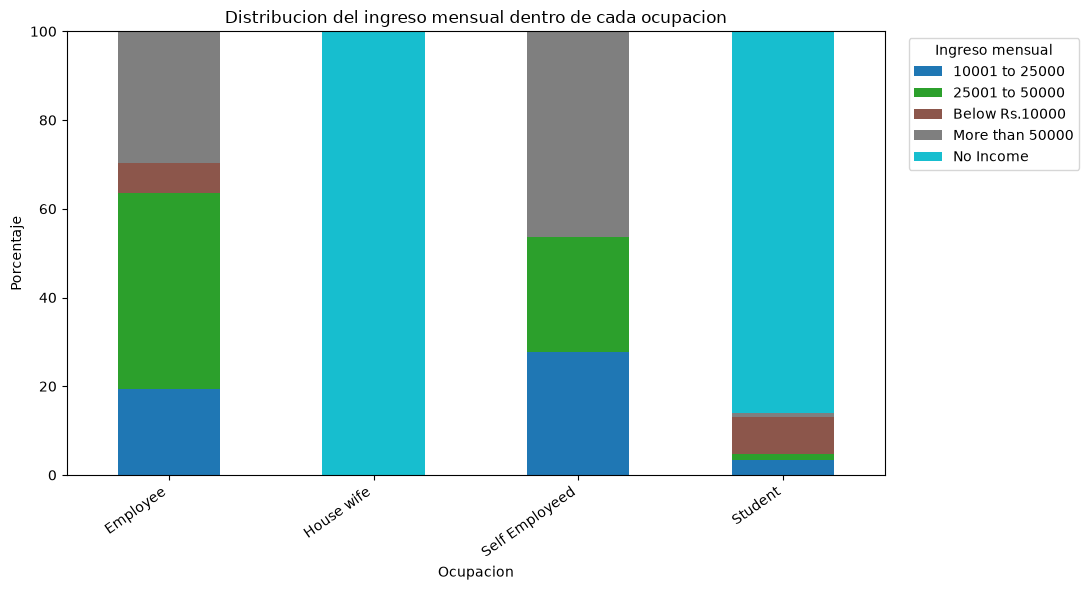

In [5]:
ax = porcentajes.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab10')
ax.set_title('Distribucion del ingreso mensual dentro de cada ocupacion')
ax.set_xlabel('Ocupacion')
ax.set_ylabel('Porcentaje')
ax.legend(title='Ingreso mensual', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [6]:
chi2, p_valor, grados_libertad, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
filas, columnas = tabla.shape
phi2 = chi2 / n
phi2_corregido = max(0, phi2 - ((columnas - 1) * (filas - 1)) / (n - 1))
filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)
v_cramer = (phi2_corregido / max(1, min(columnas_corregidas - 1, filas_corregidas - 1))) ** 0.5
print(f'Chi-cuadrado: {chi2:.3f} | gl: {grados_libertad} | p-valor: {p_valor:.6g}')
print(f"V de Cramer (corregida): {v_cramer:.3f}")
print('Asociacion estadisticamente significativa (alpha=0.05).' if p_valor < 0.05 else 'No se detecta asociacion estadisticamente significativa (alpha=0.05).')

Chi-cuadrado: 341.996 | gl: 12 | p-valor: 6.84101e-66
V de Cramer (corregida): 0.534
Asociacion estadisticamente significativa (alpha=0.05).


,variable,tipo_analitico,dtype_pandas,categorias_observadas
0,Occupation,Categórica nominal,str,"[Employee, House wife, Self Employeed, Student]"
1,Monthly Income,Categórica ordinal (tramos de ingreso),str,"[10001 to 25000, 25001 to 50000, Below Rs.1000..."


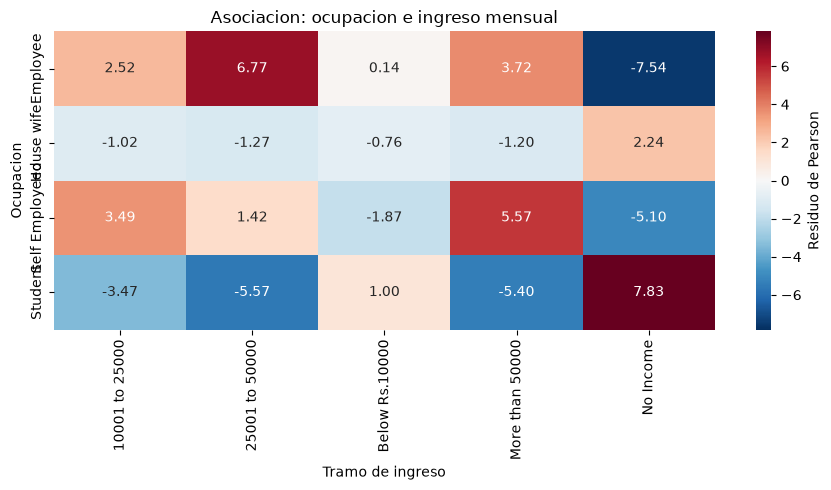

V de Cramer corregida: 0.534
Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.


In [7]:
import numpy as np
import seaborn as sns

variables = ["Occupation", "Monthly Income"]
tipos = ["Categórica nominal", "Categórica ordinal (tramos de ingreso)"]
resumen_tipos = pd.DataFrame(
    {
        "variable": variables,
        "tipo_analitico": tipos,
        "dtype_pandas": [str(df[variable].dtype) for variable in variables],
        "categorias_observadas": [
            sorted(df[variable].dropna().unique().tolist())
            for variable in variables
        ],
    }
)
display(resumen_tipos)

_, _, _, esperadas_heatmap = chi2_contingency(tabla, correction=False)
residuos_pearson = (tabla - esperadas_heatmap) / np.sqrt(esperadas_heatmap)
limite_color = max(abs(residuos_pearson.to_numpy()).max(), 1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    residuos_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-limite_color,
    vmax=limite_color,
    cbar_kws={"label": "Residuo de Pearson"},
    ax=ax,
)
ax.set_title("Asociacion: ocupacion e ingreso mensual")
ax.set_xlabel("Tramo de ingreso")
ax.set_ylabel("Ocupacion")
plt.tight_layout()
plt.show()
print(f"V de Cramer corregida: {v_cramer:.3f}")
print("Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.")